In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from tqdm import tqdm
import os

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
class PersianPoetryDataset(Dataset):
    """
    Custom Dataset for Persian Poetry
    """
    def __init__(self, sequences, targets):
        self.sequences = torch.LongTensor(sequences)
        self.targets = torch.LongTensor(targets)

    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

In [5]:
class LSTMModel(nn.Module):
    """LSTM Model for text generation"""
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers,
                  dropout=0.3, bidirectional=False):
        super(LSTMModel, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # LSTM layers
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Output layer
        self.fc = nn.Linear(hidden_dim * self.num_directions, vocab_size)
    
    def forward(self, x, hidden=None):
        # x shape: (batch_size, seq_length)
        embedded = self.embedding(x)  # (batch_size, seq_length, embedding_dim)
        
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)
        
        # Take the last output
        lstm_out = lstm_out[:, -1, :]  # (batch_size, hidden_dim * num_directions)
        
        # Apply dropout
        lstm_out = self.dropout(lstm_out)
        
        # Output layer
        output = self.fc(lstm_out)  # (batch_size, vocab_size)
        
        return output, hidden
    
    def init_hidden(self, batch_size):
        """Initialize hidden state"""
        h0 = torch.zeros(self.num_layers * self.num_directions, batch_size, self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers * self.num_directions, batch_size, self.hidden_dim).to(device)
        return (h0, c0)


In [ ]:
class PersianPoetryLSTM:
    def __init__(self, seq_length=40, embedding_dim=128, hidden_dim=256,
                  num_layers=2, dropout=0.3):
        self.seq_length = seq_length
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout = dropout
        self.model = None
        self.char_to_idx = {}
        self.idx_to_char = {}
        self.vocab_size = 0
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        self.device = torch.device('cpu')
    
    def load_data_from_folder(self, folder_path, folder_type=None):
        """Load all .txt files from specified folder"""
        print(f"Loading data from {folder_type} folder...")
        
        if folder_type != None:
            target_folder = Path(folder_path) / folder_type
        else:
            target_folder = Path(folder_path)
        
        if not target_folder.exists():
            raise FileNotFoundError(f"Folder not found: {target_folder}")
        
        all_text = []
        txt_files = list(target_folder.glob('*.txt'))
        
        print(f"Found {len(txt_files)} text files")
        
        for txt_file in txt_files:
            try:
                with open(txt_file, 'r', encoding='utf-8') as f:
                    content = f.read()
                    all_text.append(content)
                    print(f"  Loaded: {txt_file.name} ({len(content)} chars)")
            except Exception as e:
                print(f"  Error loading {txt_file.name}: {e}")
        
        # Combine all texts
        text = '\n'.join(all_text)
        print(f"\nTotal characters: {len(text)}")
        
        return text
    
    def preprocess_data(self, text):
        """Create character vocabulary and convert text to indices"""
        print("\nPreprocessing data...")
        
        # Create character vocabulary
        chars = sorted(list(set(text)))
        self.vocab_size = len(chars)
        print(f"Vocabulary size: {self.vocab_size}")
        
        # Create mappings
        self.char_to_idx = {ch: i for i, ch in enumerate(chars)}
        self.idx_to_char = {i: ch for i, ch in enumerate(chars)}
        
        # Convert text to indices
        text_as_int = np.array([self.char_to_idx[c] for c in text])
        
        return text_as_int
    
    def create_sequences(self, text_as_int):
        """Create input-output sequences for training"""
        print(f"\nCreating sequences of length {self.seq_length}...")
        
        sequences = []
        targets = []
        
        for i in range(0, len(text_as_int) - self.seq_length):
            sequences.append(text_as_int[i:i + self.seq_length])
            targets.append(text_as_int[i + self.seq_length])
        
        X = np.array(sequences)
        y = np.array(targets)
        
        print(f"Number of sequences: {len(X)}")
        print(f"Input shape: {X.shape}")
        print(f"Target shape: {y.shape}")
        
        return X, y
    
    def build_model(self, bidirectional=False):
        """Build LSTM model"""
        print("\nBuilding model...")
        
        self.model = LSTMModel(
            vocab_size=self.vocab_size,
            embedding_dim=self.embedding_dim,
            hidden_dim=self.hidden_dim,
            num_layers=self.num_layers,
            dropout=self.dropout,
            bidirectional=bidirectional
        ).to(device)
        
        # Print model summary
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        
        print(f"\nModel Architecture:")
        print(self.model)
        print(f"\nTotal parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
        
        return self.model
    
    def train_epoch(self, dataloader, criterion, optimizer):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for sequences, targets in tqdm(dataloader, desc="Training"):
            sequences = sequences.to(device)
            targets = targets.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs, _ = self.model(sequences)
            loss = criterion(outputs, targets)
            
            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)
            optimizer.step()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        accuracy = 100 * correct / total
        
        return avg_loss, accuracy
    
    def validate(self, dataloader, criterion):
        """Validate the model"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for sequences, targets in dataloader:
                sequences = sequences.to(device)
                targets = targets.to(device)
                
                outputs, _ = self.model(sequences)
                loss = criterion(outputs, targets)
                
                _, predicted = torch.max(outputs, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()
                total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        accuracy = 100 * correct / total
        
        return avg_loss, accuracy
    
    def train(self, X, y, epochs=30, batch_size=128, validation_split=0.1, learning_rate=0.001):
        """Train the model"""
        print("\n" + "="*60)
        print("TRAINING")
        print("="*60)
        
        # Split data
        split_idx = int(len(X) * (1 - validation_split))
        X_train, X_val = X[:split_idx], X[split_idx:]
        y_train, y_val = y[:split_idx], y[split_idx:]
        
        # Create datasets and dataloaders
        train_dataset = PersianPoetryDataset(X_train, y_train)
        val_dataset = PersianPoetryDataset(X_val, y_val)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) # TODO: , verbose=True
        
        # Training loop
        best_val_loss = float('inf')
        patience = 5
        patience_counter = 0
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            print("-" * 60)
            
            # Train
            train_loss, train_acc = self.train_epoch(train_loader, criterion, optimizer)
            
            # Validate
            val_loss, val_acc = self.validate(val_loader, criterion)
            
            # Save history
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
            
            # Learning rate scheduling
            scheduler.step(val_loss)
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_model.pth')
                print("✓ Best model saved")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\nEarly stopping triggered after {epoch+1} epochs")
                    break
        
        # Load best model
        self.model.load_state_dict(torch.load('best_model.pth'))
        print("\n✓ Training complete! Best model loaded.")
    
    def plot_training_history(self):
        """Plot training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        epochs = range(1, len(self.history['train_loss']) + 1)
        
        # Loss plot
        ax1.plot(epochs, self.history['train_loss'], 'b-', label='Training Loss', linewidth=2)
        ax1.plot(epochs, self.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.set_title('Model Loss', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        
        # Accuracy plot
        ax2.plot(epochs, self.history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
        ax2.plot(epochs, self.history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
        ax2.set_xlabel('Epoch', fontsize=12)
        ax2.set_ylabel('Accuracy (%)', fontsize=12)
        ax2.set_title('Model Accuracy', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_history_pytorch.png', dpi=300, bbox_inches='tight')
        print("\n✓ Training history saved to 'training_history_pytorch.png'")
        plt.show()
    
    def generate_text(self, seed_text, num_chars=200, temperature=1.0):
        """Generate text using the trained model"""
        self.model.eval()
        generated = seed_text
        
        with torch.no_grad():
            for _ in range(num_chars):
                # Prepare input
                x = torch.zeros((1, self.seq_length), dtype=torch.long)
                for t, char in enumerate(seed_text[-self.seq_length:]):
                    if char in self.char_to_idx:
                        x[0, t] = self.char_to_idx[char]
                
                x = x.to(self.device)
                
                # Predict next character
                output, _ = self.model(x)
                output = output.cpu().numpy()[0]
                
                # Apply temperature with numerical stability
                output = output / temperature
                output = output - np.max(output)  # Subtract max for stability
                exp_output = np.exp(output)
                output = exp_output / np.sum(exp_output)
                
                # Check for NaN and handle edge cases
                if np.isnan(output).any() or np.sum(output) == 0:
                    output = np.ones(len(output)) / len(output)
                
                # Sample next character
                next_idx = np.random.choice(len(output), p=output)
                next_char = self.idx_to_char[next_idx]
                
                generated += next_char
                seed_text += next_char
        
        return generated
  
    def save_model(self, path='persian_poetry_model_pytorch.pth'):
        """Save the trained model and vocabulary"""
        # Save model
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'vocab_size': self.vocab_size,
            'embedding_dim': self.embedding_dim,
            'hidden_dim': self.hidden_dim,
            'num_layers': self.num_layers,
            'seq_length': self.seq_length
        }, path)
        
        # Save vocabulary
        vocab_data = {
            'char_to_idx': self.char_to_idx,
            'idx_to_char': {int(k): v for k, v in self.idx_to_char.items()},
            'vocab_size': self.vocab_size,
            'seq_length': self.seq_length
        }
        
        with open('vocabulary_pytorch.json', 'w', encoding='utf-8') as f:
            json.dump(vocab_data, f, ensure_ascii=False, indent=2)
        
        print(f"\n✓ Model saved to {path}")
        print("✓ Vocabulary saved to vocabulary_pytorch.json")


In [14]:
def main():
    """Main execution function"""
    
    # Initialize the model
    lstm_model = PersianPoetryLSTM(
        seq_length=40,
        embedding_dim=128,
        hidden_dim=256,
        num_layers=2,
        dropout=0.3
    )
    
    # Step 1: Load data from folder structure
    print("="*60)
    print("STEP 1: DATA LOADING")
    print("="*60)
    
    # Specify the path to the Persian_poems_corpus folder
    dataset_path = './data'  # Adjust this path
    
    # Choose which folder to use: 'normalized', 'original', or 'stop_words_removed'
    text = lstm_model.load_data_from_folder(dataset_path)
    
    # Show sample
    print(f"\nSample text:\n{text[:300]}")
    
    # Step 2: Preprocess data
    print("\n" + "="*60)
    print("STEP 2: DATA PREPROCESSING")
    print("="*60)
    text_as_int = lstm_model.preprocess_data(text)
    
    # Step 3: Create sequences
    print("\n" + "="*60)
    print("STEP 3: SEQUENCE CREATION")
    print("="*60)
    X, y = lstm_model.create_sequences(text_as_int)
    
    # Step 4: Build model
    print("\n" + "="*60)
    print("STEP 4: MODEL ARCHITECTURE")
    print("="*60)
    lstm_model.build_model(bidirectional=False)
    
    # Step 5: Train model
    lstm_model.train(
        X, y,
        epochs=3,
        batch_size=128,
        validation_split=0.1,
        learning_rate=0.001
    )
    
    # Step 6: Visualize results
    print("\n" + "="*60)
    print("STEP 6: TRAINING VISUALIZATION")
    print("="*60)
    lstm_model.plot_training_history()
    
    # Step 7: Generate text
    print("\n" + "="*60)
    print("STEP 7: TEXT GENERATION")
    print("="*60)
    
    # Use a seed from the original text
    seed_text = text[:40]
    print(f"Seed text: {seed_text}\n")
    
    for temp in [0.5, 1.0, 1.5]:
        print(f"\n{'='*60}")
        print(f"Temperature: {temp}")
        print('='*60)
        generated = lstm_model.generate_text(seed_text, num_chars=200, temperature=temp)
        print(generated)
    
    # Step 8: Save model
    print("\n" + "="*60)
    print("STEP 8: SAVING MODEL")
    print("="*60)
    lstm_model.save_model()
    
    print("\n" + "="*60)
    print("✓ TRAINING COMPLETE!")
    print("="*60)

STEP 1: DATA LOADING
Loading data from None folder...
Found 624 text files
  Loaded: ferdousi_shahname_eskandar_sh36.txt (2848 chars)
  Loaded: ferdousi_shahname_eskandar_sh22.txt (2640 chars)
  Loaded: ferdousi_shahname_esfandyar_sh19.txt (4753 chars)
  Loaded: ferdousi_shahname_parviz_sh50.txt (2759 chars)
  Loaded: ferdousi_shahname_zahak_sh11.txt (2712 chars)
  Loaded: ferdousi_shahname_parviz_sh44.txt (1417 chars)
  Loaded: ferdousi_shahname_bezehgar_sh17.txt (1707 chars)
  Loaded: ferdousi_shahname_esfandyar_sh25.txt (1460 chars)
  Loaded: ferdousi_shahname_ashkanian_sh4.txt (1429 chars)
  Loaded: ferdousi_shahname_esfandyar_sh31.txt (3317 chars)
  Loaded: ferdousi_shahname_hamavaran_sh3.txt (4257 chars)
  Loaded: ferdousi_shahname_fereydoon_sh8.txt (987 chars)
  Loaded: ferdousi_shahname_ashkanian_sh17.txt (1671 chars)
  Loaded: ferdousi_shahname_zolaktaf_sh16.txt (3022 chars)
  Loaded: ferdousi_shahname_manoochehr_sh2.txt (6247 chars)
  Loaded: ferdousi_shahname_goshtasp_sh1.tx

Training: 100%|██████████| 17968/17968 [29:45<00:00, 10.06it/s]


Train Loss: 1.6305 | Train Acc: 50.57%
Val Loss: 1.4096 | Val Acc: 55.69%
✓ Best model saved

Epoch 2/3
------------------------------------------------------------


Training: 100%|██████████| 17968/17968 [29:07<00:00, 10.28it/s]


Train Loss: 1.4394 | Train Acc: 56.21%
Val Loss: 1.3369 | Val Acc: 58.67%
✓ Best model saved

Epoch 3/3
------------------------------------------------------------


Training: 100%|██████████| 17968/17968 [52:18<00:00,  5.72it/s]   


Train Loss: 1.4019 | Train Acc: 57.30%
Val Loss: 1.3140 | Val Acc: 59.26%
✓ Best model saved

✓ Training complete! Best model loaded.

STEP 6: TRAINING VISUALIZATION

✓ Training history saved to 'training_history_pytorch.png'


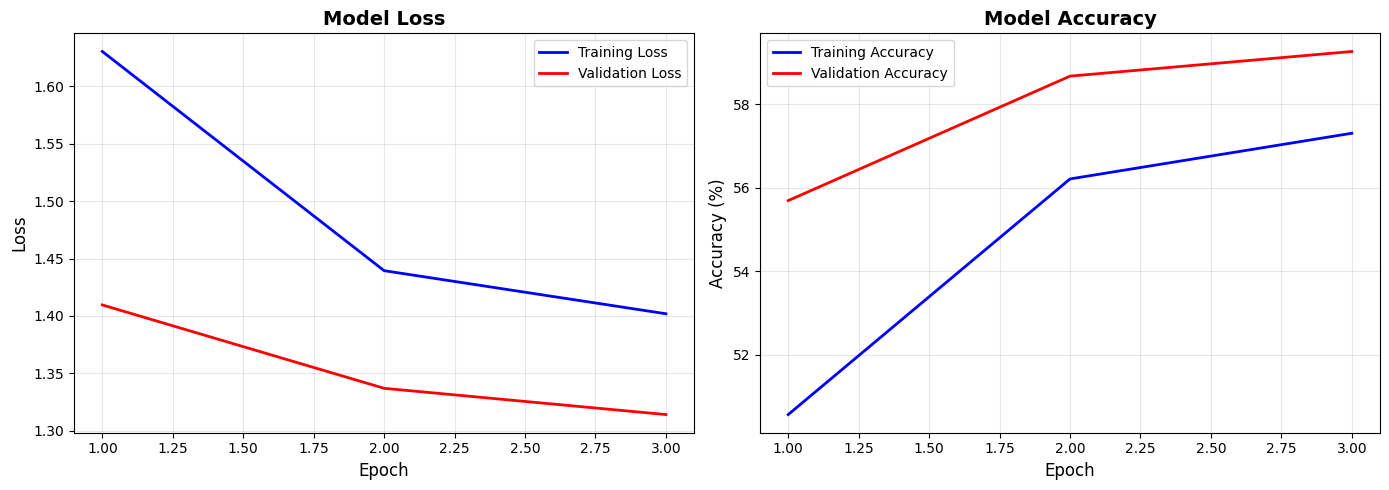


STEP 7: TEXT GENERATION
Seed text: سوی باختر شد چو خاور بدید	ز گیتی همی رای


Temperature: 0.5
سوی باختر شد چو خاور بدید	ز گیتی همی رای کشور به زار
بدان تا برآمد ز ایرانیان	نه باشد به بیچارگی با سپاه
بدو گفت کای خواند آن پیش اوی	همی با سپهدار با او به جنگ
چو از چاره باید چو گردان سپاه	بدان مرد بر زان سخن بر سرش
چو آگاهی آمد ز ما را ب

Temperature: 1.0
سوی باختر شد چو خاور بدید	ز گیتی همی رای ازین بس به فال
جهاندار باید وزان خواب تیغ	ربیده پر از روشن ریختند
همه پیش دینار خنجر سوار	اگر سودمندش مگون و ز ایوان بدوی
بیامد برو ارجمند افسرش	نباید که سالش دل می گهر
بباید کرد بر چه بالوی رنج	که م

Temperature: 1.5
سوی باختر شد چو خاور بدید	ز گیتی همی رای کشورش اژد
گودرز رفتند شاهان بجنگ	به پیرایستهیی راستان سام
بجنگیغ خواه گذشتی صیان	سه کاریش نربسته گیو خون
کهترخشکی آشکی عرگمند	درون‌یمفگن زاهش من به پشت
مگر آنکز ابرت زهاره غنی	که دینار از آخر روان با

STEP 8: SAVING MODEL

✓ Model saved to persian_poetry_model_pytorch.pth
✓ Vocabulary saved to vocabulary_pytorch.json

✓ TRAINING COMPLETE!


In [15]:
main()

In [16]:
from pathlib import Path

In [29]:
path = './data'
folder_name = Path(path)
list_txt_files = list(folder_name.glob('*.txt'))
len(list_txt_files)

624

In [55]:
total_characters = 0
total_content = []
for file in list_txt_files[:]:
    with open(file, 'r', encoding='utf-8') as f:
        content = f.read()
        total_characters += len(content)
        total_content.append(content)
print(f"Total characters in first 10 files: {total_characters}")
# print('\n'.join(total_content))
text = '\n'.join(total_content)
print(len(text))
print(set(text))
text = list(set(text))

char_to_idx = {ch: i for i, ch in enumerate(text)}
print(len(text))

char_to_idx


Total characters in first 10 files: 2576479
2577102
{'پ', ' ', 'ر', '\u200c', 'ش', 'ژ', '،', 'ث', 'خ', 'ف', 'ص', 'ؤ', 'ی', 'س', 'ع', 'ز', 'ب', '\t', '\n', 'ذ', 'و', 'غ', 'ک', 'ئ', 'ج', 'ظ', 'أ', ')', 'م', 'ض', 'ح', 'ا', 'ت', 'ط', 'ن', 'ء', 'آ', 'ل', 'ق', '«', 'چ', '»', '(', 'د', 'ه', '؟', 'گ', 'ٔ'}
48


{'پ': 0,
 ' ': 1,
 'ر': 2,
 '\u200c': 3,
 'ش': 4,
 'ژ': 5,
 '،': 6,
 'ث': 7,
 'خ': 8,
 'ف': 9,
 'ص': 10,
 'ؤ': 11,
 'ی': 12,
 'س': 13,
 'ع': 14,
 'ز': 15,
 'ب': 16,
 '\t': 17,
 '\n': 18,
 'ذ': 19,
 'و': 20,
 'غ': 21,
 'ک': 22,
 'ئ': 23,
 'ج': 24,
 'ظ': 25,
 'أ': 26,
 ')': 27,
 'م': 28,
 'ض': 29,
 'ح': 30,
 'ا': 31,
 'ت': 32,
 'ط': 33,
 'ن': 34,
 'ء': 35,
 'آ': 36,
 'ل': 37,
 'ق': 38,
 '«': 39,
 'چ': 40,
 '»': 41,
 '(': 42,
 'د': 43,
 'ه': 44,
 '؟': 45,
 'گ': 46,
 'ٔ': 47}

In [56]:
def text_to_int(text):
    array = np.array([char_to_idx[ch] for ch in text])
    return array

In [62]:
text_as_int = text_to_int('\n'.join(total_content))
print(text_as_int[:100])


[13 20 12  1 16 31  8 32  2  1  4 43  1 40 20  1  8 31 20  2  1 16 43 12
 43 17 15  1 46 12 32 12  1 44 28 12  1  2 31 12  1  2  9 32 34  1 46 15
 12 43 18 16  2 44  3 16  2  1 12 22 12  1  4 31  2 13 32 31 34  1 43 12
 43  1  0 31 22 17 22 44  1 34 46 19  4 32  1 46 20 12 12  1 16  2 20 16
 31 43  1 20]


In [64]:
seq_length = 20
sequences = []
targets = []
for i in range(0, len(text_as_int) - seq_length):
    sequences.append(text_as_int[i: i + seq_length])
    targets.append(text_as_int[i + seq_length])
print(f"Number of sequences: {len(sequences)}")
print(f"Example sequence: {sequences[0]}")
print(f"Example target: {targets[0]}")
X = np.array(sequences)
y = np.array(targets) 

Number of sequences: 2577082
Example sequence: [13 20 12  1 16 31  8 32  2  1  4 43  1 40 20  1  8 31 20  2]
Example target: 1


In [65]:
print(X.shape)
print(y.shape)

(2577082, 20)
(2577082,)
